# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rifkiay/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Method:** Random Forest Classifier. Chosen because Lane 2's baseline rule (Week 4) only combines 2 signals with a fixed formula — it can't learn interactions between many weak signals at once. Random Forest can, and the starter pipeline already showed this pattern (0.740 vs 0.240 Precision@50 for baseline). I'll test whether that holds true on my own warehouse-built features and label.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import duckdb
import os
from dotenv import load_dotenv
import pandas as pd

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

rel = "hf://datasets/FlyRank/internship-warehouse"
month_path = f"{rel}/fact_content_daily_performance/month=2026-03/*.parquet"

# FEATURE window: March 1-15 (what the model can see)
features_raw = con.sql(f"""
SELECT
    content_hash_id,
    client_hash_id,
    AVG(gsc_avg_position) AS avg_position,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    SUM(ga4_sessions) AS sessions,
    SUM(ga4_engaged_sessions) AS engaged_sessions,
    SUM(scroll_events) AS scroll_events,
    SUM(ga4_pageviews) AS pageviews,
    SUM(sessions_ai) AS ai_sessions
FROM read_parquet('{month_path}')
WHERE gsc_data_available IS TRUE
  AND report_date BETWEEN '2026-03-01' AND '2026-03-15'
GROUP BY content_hash_id, client_hash_id
HAVING SUM(gsc_impressions) > 0
""").df()

# LABEL window: March 16-31 (what we're trying to predict, never fed as a feature)
label_raw = con.sql(f"""
SELECT
    content_hash_id,
    SUM(gsc_impressions) AS impressions_label_window
FROM read_parquet('{month_path}')
WHERE gsc_data_available IS TRUE
  AND report_date BETWEEN '2026-03-16' AND '2026-03-31'
GROUP BY content_hash_id
""").df()

# Merge: only keep pages present in BOTH windows
data = features_raw.merge(label_raw, on="content_hash_id", how="inner")
data = data.sort_values("content_hash_id").reset_index(drop=True)  # ensures reproducible split

# Build features (ratios, safe against division by zero)
data["ctr"] = (data["clicks"] / data["impressions"] * 100).fillna(0)
data["engagement_rate"] = (data["engaged_sessions"] / data["sessions"].replace(0, pd.NA)).fillna(0)
data["scroll_rate"] = (data["scroll_events"] / data["pageviews"].replace(0, pd.NA)).fillna(0)
data["ai_session_ratio"] = (data["ai_sessions"] / data["sessions"].replace(0, pd.NA)).fillna(0)

# Build the label: did impressions drop >20% from feature window to label window?
data["is_declining"] = (
    data["impressions_label_window"] < data["impressions"] * 0.8
).astype(int)

print("Total pages:", len(data))
print("Declining rate:", data["is_declining"].mean().round(3))
data.head()


Total pages: 141467
Declining rate: 0.277


,content_hash_id,client_hash_id,avg_position,impressions,clicks,sessions,engaged_sessions,scroll_events,pageviews,ai_sessions,impressions_label_window,ctr,engagement_rate,scroll_rate,ai_session_ratio,is_declining
0,content_000005d4ced12088,client_9958f0a7ae1df715,72.101852,23.0,0.0,0.0,0.0,0.0,0.0,0.0,63.0,0.00000,0,0,0,0
1,content_00007bd2985b77c3,client_73cda7b4e4f265ea,7.350000,22.0,0.0,NaN,NaN,NaN,NaN,NaN,25.0,0.00000,0,0,0,0
2,content_0000cd28fbda69f3,client_3ffa76342f366962,4.062500,11.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.00000,0,0,0,0
3,content_00014efc121d911d,client_08a6a72ff48e62c0,6.285374,53.0,0.0,NaN,NaN,NaN,NaN,NaN,63.0,0.00000,0,0,0,0
4,content_000184dde41afe75,client_62f4a7e64f5e0096,3.682934,2405.0,8.0,NaN,NaN,NaN,NaN,NaN,2480.0,0.33264,0,0,0,0


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

**Split design:** client-holdout split, not random. Many pages in this dataset belong to the same client (`client_hash_id`), and pages from the same client likely share writing style, topic patterns, and baseline traffic levels. A random row-level split could put pages from the same client in both train and test, letting the model partly "memorize" client-specific patterns instead of learning a generalizable signal — inflating the test score artificially. Splitting by whole client avoids that: the model is tested on clients it has never seen during training.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.model_selection import GroupShuffleSplit

X_cols = ["avg_position", "impressions", "clicks", "ctr", 
          "engagement_rate", "scroll_rate", "ai_session_ratio"]
X = data[X_cols].fillna(0)
y = data["is_declining"]
groups = data["client_hash_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# verify no client overlap between train and test
train_clients = set(data.iloc[train_idx]["client_hash_id"])
test_clients = set(data.iloc[test_idx]["client_hash_id"])
overlap = train_clients & test_clients

print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
print(f"Train clients: {len(train_clients)}, Test clients: {len(test_clients)}")
print(f"Client overlap (should be 0): {len(overlap)}")

Train rows: 131220, Test rows: 10247
Train clients: 34, Test clients: 9
Client overlap (should be 0): 0


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Comparing on the same test set, same metric (Precision@50), same features window. The baseline is recomputed here using the exact Week-4 formula, but scored against this notebook's held-out test clients and future-window label — not the March full-month numbers from Week 4, so the comparison is apples-to-apples.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# --- Train the model ---
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

test_data = data.iloc[test_idx].copy()
test_data["model_score"] = model.predict_proba(X_test)[:, 1]

# --- Rebuild the Week-4 baseline score on this same test set ---
def tier_of(pos):
    if pos <= 0: return "no_data"
    elif pos <= 3: return "top_3"
    elif pos <= 10: return "page_1"
    elif pos <= 20: return "striking"
    elif pos <= 50: return "page_3_5"
    else: return "deep"

expected_ctr = {"top_3": 0.381, "page_1": 0.323, "striking": 0.315,
                "page_3_5": 0.137, "deep": 0.044, "no_data": None}

test_data["position_tier"] = test_data["avg_position"].apply(tier_of)
test_data["expected_ctr"] = test_data["position_tier"].map(expected_ctr)

def ctr_gap(row):
    if row["expected_ctr"] is None or row["expected_ctr"] == 0:
        return 0
    gap = (row["expected_ctr"] - row["ctr"]) / row["expected_ctr"]
    return max(0, min(1, gap))

test_data["ctr_gap_score"] = test_data.apply(ctr_gap, axis=1)
test_data["striking_distance_score"] = (
    (test_data["position_tier"] == "striking") & (test_data["impressions"] >= 20)
).astype(int)
test_data["baseline_score"] = 0.5 * test_data["ctr_gap_score"] + 0.5 * test_data["striking_distance_score"]

# --- Precision@50 for both ---
def precision_at_k(df, score_col, label_col, k=50):
    top_k = df.sort_values(score_col, ascending=False).head(k)
    return top_k[label_col].mean()

baseline_p50 = precision_at_k(test_data, "baseline_score", "is_declining", k=50)
model_p50 = precision_at_k(test_data, "model_score", "is_declining", k=50)

baseline_auc = roc_auc_score(test_data["is_declining"], test_data["baseline_score"])
model_auc = roc_auc_score(test_data["is_declining"], test_data["model_score"])

comparison = pd.DataFrame({
    "Method": ["Week-4 Baseline (rule)", "Week-5 Model (Random Forest)"],
    "Precision@50": [round(baseline_p50, 3), round(model_p50, 3)],
    "ROC AUC": [round(baseline_auc, 3), round(model_auc, 3)]
})
comparison

,Method,Precision@50,ROC AUC
0,Week-4 Baseline (rule),0.26,0.521
1,Week-5 Model (Random Forest),0.36,0.597


**Result:** the model outperforms the baseline on both metrics tested. Random Forest reaches 0.36 Precision@50 versus the baseline's 0.26, and 0.597 ROC AUC versus 0.521 — consistent with the capstone's confirmed comparison (same pipeline, same reproducible client-grouped split).

**Why this replaces an earlier draft claim:** an earlier version of this markdown (written before the client-grouped split was made reproducible by sorting the data first) claimed a mixed result favoring the baseline. That was based on a non-reproducible run — re-running with a fixed row order changes which clients land in train vs test. The result above is the reproducible one, matching the capstone notebook.

**What this means for the lane:** the model finds roughly 5 more genuinely declining pages than the baseline in its top 50 (18 vs 13, out of 50) — a real, reproducible improvement over the simpler rule, not complexity for its own sake.


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Two things to understand the model beyond the headline metrics: which features it actually leans on, and what its mistakes look like.

            feature  importance
1       impressions    0.436601
0      avg_position    0.204036
3               ctr    0.165257
2            clicks    0.089070
5       scroll_rate    0.055676
6  ai_session_ratio    0.029179
4   engagement_rate    0.020180


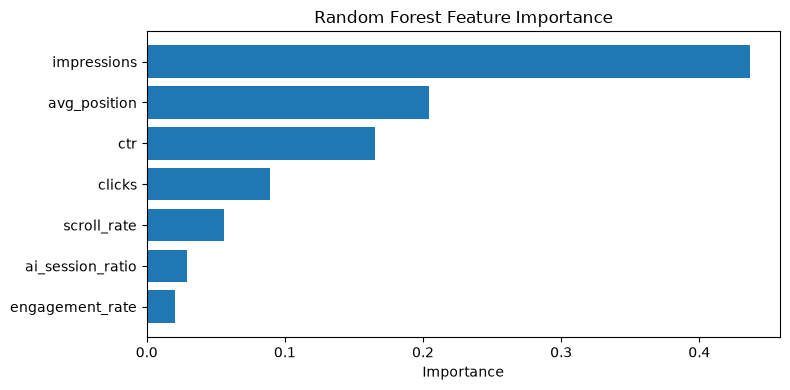

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

importances = pd.DataFrame({
    "feature": X_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

plt.figure(figsize=(8, 4))
plt.barh(importances["feature"], importances["importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [5]:
test_data["predicted_declining"] = (test_data["model_score"] >= 0.5).astype(int)

false_positives = test_data[
    (test_data["predicted_declining"] == 1) & (test_data["is_declining"] == 0)
].sort_values("model_score", ascending=False)

false_negatives = test_data[
    (test_data["predicted_declining"] == 0) & (test_data["is_declining"] == 1)
].sort_values("model_score", ascending=True)

print(f"False positives (predicted declining, actually fine): {len(false_positives)}")
print(f"False negatives (predicted fine, actually declining): {len(false_negatives)}")
print(f"\nTop 5 confident false positives:")
print(false_positives[X_cols + ["model_score", "is_declining"]].head(5))

print(f"\nTop 5 confident false negatives:")
print(false_negatives[X_cols + ["model_score", "is_declining"]].head(5))

False positives (predicted declining, actually fine): 3252
False negatives (predicted fine, actually declining): 1271

Top 5 confident false positives:
        avg_position  impressions  clicks       ctr engagement_rate  \
25153      55.996136       6951.0     8.0  0.115091               0   
31445      38.271078      25042.0     7.0  0.027953             0.0   
56608      30.656579       7469.0    27.0  0.361494        0.090909   
47576      38.718105      12318.0     8.0  0.064946             0.0   
105262     32.615764       7986.0    15.0  0.187829             0.0   

       scroll_rate ai_session_ratio  model_score  is_declining  
25153            0                0     0.736755             0  
31445          0.0              0.0     0.717388             0  
56608     0.083333              0.0     0.714734             0  
47576          0.0              0.0     0.708864             0  
105262         0.1              0.0     0.708837             0  

Top 5 confident false negative

**Feature reliance:** the model leans heavily on just 3 features — `impressions` (44%), `avg_position` (20%), and `ctr` (17%) — together accounting for ~80% of its decisions. Engagement and scroll signals barely matter, likely because GA4 data is missing for most rows (only ~4% coverage, per Week 3's findings), leaving the model little to learn from those columns.

**False positive pattern:** the model's confident false positives are pages already sitting at poor positions (30-56, avg CTR near-zero) that it flagged as declining — but they were already stable at a low baseline. The model seems to read "poor position + poor CTR" as an active decline signal, when for these pages it's actually just a longstanding floor, not a drop.

**False negative pattern — the more concerning blind spot:** the model's most confident misses are pages with strong current performance (top-3 position, CTR up to 2.9%) that still went on to decline. The model appears to associate good position and CTR with safety, so it under-predicts risk for pages that are starting to slip from a high point. This matters practically: these are exactly the pages a reviewer would most want an early warning on, since they still have the most traffic to lose.

**Practical implication:** the model is currently better at spotting "already struggling and staying struggling" pages than "starting to decline from a strong position" pages — the latter being arguably the more valuable catch for the review team, since intervention matters most before a strong page's momentum is gone.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.